# T11d — Transformer (Encoder-only)

Uses `deep_learning.py` for all shared setup, training and evaluation.

**Model:** Encoder-only Transformer — multi-head self-attention over the W-cycle window. Mean-pools the sequence output before the regression head.

In [1]:
import sys, os
from pathlib import Path

ROOT = Path(os.getcwd()).resolve().parents[1]
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print(f"Project root: {ROOT}")

Project root: /Users/dhruvparmar/DAU/sem_2/IT_402_Applied_Forecasting_Methods/Project/Aircraft Engine Failure Forecasting


In [2]:
from src.models.deep_learning import *
import torch.nn as nn

print(f"Device: {DEVICE}")


Device: mps


## 1. Load data & build windows

In [3]:
train_df, test_df = load_data()
FEAT_COLS  = select_features(train_df)
N_FEATURES = len(FEAT_COLS)

X_train, y_train, X_val, y_val = engine_split(train_df, FEAT_COLS)
X_test, y_test = build_windows(test_df, FEAT_COLS, is_test=True)

train_loader, val_loader, test_loader = make_loaders(
    X_train, y_train, X_val, y_val, X_test, y_test
)


Train shape : (61249, 105)  (249 engines)
Test  shape : (41214, 105)   (248 engines)
Feature columns (42): ['s2_rmean_5', 's3_rmean_5', 's4_rmean_5', 's7_rmean_5', 's8_rmean_5'] ...
Train engines: 199  Val engines: 50
X_train: (42725, 30, 42)  X_val: (50, 30, 42)
Train batches: 334  Val batches: 1


## 2. Model definition

Encoder-only Transformer:
1. Linear projection: `n_features → d_model`
2. Learnable positional encoding (one embedding per cycle position)
3. Transformer encoder (multi-head self-attention)
4. Mean pool over the sequence → global context vector
5. Linear head → RUL

> **Why mean-pool instead of last timestep?**  
> Attention already weighs all positions; mean-pooling exploits the full context rather than ignoring earlier cycles.

In [4]:
class TransformerModel(nn.Module):
    """
    Encoder-only Transformer for RUL regression.

    Architecture
    ------------
    Linear(n_features → d_model)
    + Embedding positional encoding (WINDOW_SIZE × d_model)
    → TransformerEncoder (n_heads=4, dim_ff=d_model*4, n_layers=2)
    → mean pool over sequence
    → Linear(d_model → 1)
    """
    def __init__(self, n_features, d_model=64, n_heads=4,
                 n_layers=2, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(n_features, d_model)
        # Learnable positional encoding — one vector per cycle position
        self.pos_enc    = nn.Embedding(WINDOW_SIZE, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model         = d_model,
            nhead           = n_heads,
            dim_feedforward = d_model * 4,
            dropout         = dropout,
            batch_first     = True,   # (batch, seq, d_model)
        )
        self.transformer = nn.TransformerEncoder(encoder_layer,
                                                  num_layers=n_layers)
        self.fc = nn.Linear(d_model, 1)

    def forward(self, x):
        B, W, _ = x.shape
        positions = torch.arange(W, device=x.device).unsqueeze(0)   # (1, W)
        x = self.input_proj(x) + self.pos_enc(positions)            # (B, W, d_model)
        x = self.transformer(x)                                      # (B, W, d_model)
        x = x.mean(dim=1)                                            # (B, d_model)
        return self.fc(x).squeeze(-1)                                # (B,)

model = TransformerModel(N_FEATURES)
n_params = sum(p.numel() for p in model.parameters())
print(f"Transformer parameters: {n_params:,}")


Transformer parameters: 104,705


## 3. Train

In [5]:
model, train_losses, val_losses = train_model(
    model        = model,
    train_loader = train_loader,
    val_loader   = val_loader,
    epochs       = EPOCHS,
    model_name   = "Transformer",
)


  [Transformer] Epoch  10 | train=149.8627 | val=32.5546 | best=5.4863
  [Transformer] Early stop at epoch 19


## 4. Evaluate

In [6]:
from src.evaluation.metrics import evaluate

y_true, y_pred = predict_test(model, test_loader)
results = evaluate(y_true, y_pred, model_name="Transformer")
print(results)


  [Transformer] RMSE: 13.6526  |  NASA Score: 1015.02 (mean: 4.09)  |  R2: 0.8991  |  Bias: +1.87 (late ↑)
{'rmse': 13.65259075164795, 'nasa_score': 1015.0204467773438, 'nasa_score_mean': 4.092824382166708, 'r2_score': 0.8991039991378784, 'bias': 1.866013526916504}


## 5. Plots

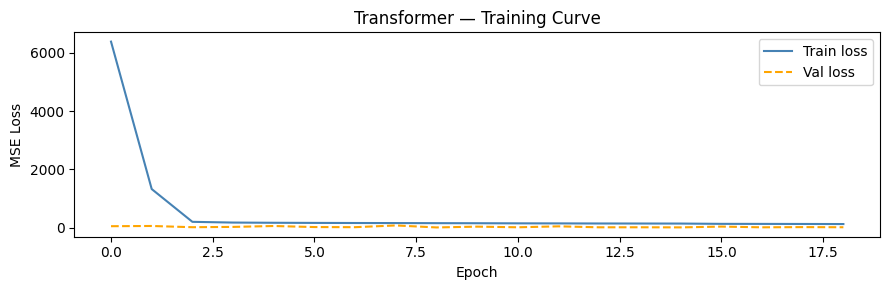

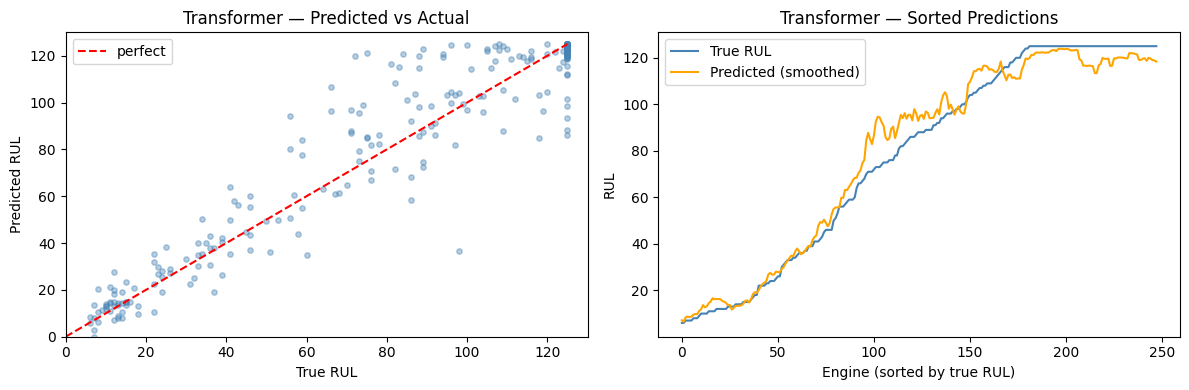

In [7]:
plot_loss_curves(train_losses, val_losses, model_name="Transformer")
plot_predictions(y_true, y_pred, model_name="Transformer")
